In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df1 = pd.read_csv('/content/student_mental_health_burnout 2.csv')
df2 = pd.read_csv('/content/student_mental_health_burnout.csv')

print(f"Dataset 1: {df1.shape}")
print(f"Dataset 2: {df2.shape}")

Dataset 1: (150000, 20)
Dataset 2: (150000, 20)


In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

In [12]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

In [4]:
df1.columns = [col.lower().strip().replace(' ', '_') for col in df1.columns]
df2.columns = [col.lower().strip().replace(' ', '_') for col in df2.columns]

df1['source'] = 'batch_1'
df2['source'] = 'batch_2'

df_combined = pd.concat([df1, df2], axis=0, ignore_index=True)

In [6]:
df_combined['age'] = pd.to_numeric(df_combined['age'], errors='coerce')

In [7]:
df_combined.drop_duplicates(inplace=True)

In [8]:
df_combined = df_combined.applymap(lambda x: x.strip() if isinstance(x, str) else x) #spacesss

if 'burnout_score' in df_combined.columns:
    median_score = df_combined['burnout_score'].median()
    df_combined['burnout_score'].fillna(median_score, inplace=True) #median to fill extra spaceszz

df_combined.to_csv('cleaned_student_burnout.csv', index=False)
print("Data cleaned and saved!")

/tmp/ipykernel_13307/512957897.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_combined = df_combined.applymap(lambda x: x.strip() if isinstance(x, str) else x)


Data cleaned and saved!


BURNOUT_LEVEL

In [14]:
df_combined['burnout_level'] = df_combined['burnout_level'].str.strip().str.capitalize() #standardlizes text and fixes capitals and stuff

print(df_combined['burnout_level'].unique()) #aany unique wrds

mode_val = df_combined['burnout_level'].mode()[0] #most frequent value in clms
df_combined['burnout_level'].fillna(mode_val, inplace=True)

['High' 'Low' 'Medium']


/tmp/ipykernel_13307/487392855.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_combined['burnout_level'].fillna(mode_val, inplace=True)


/tmp/ipykernel_13307/2981333433.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_combined, x='burnout_level', palette='viridis')


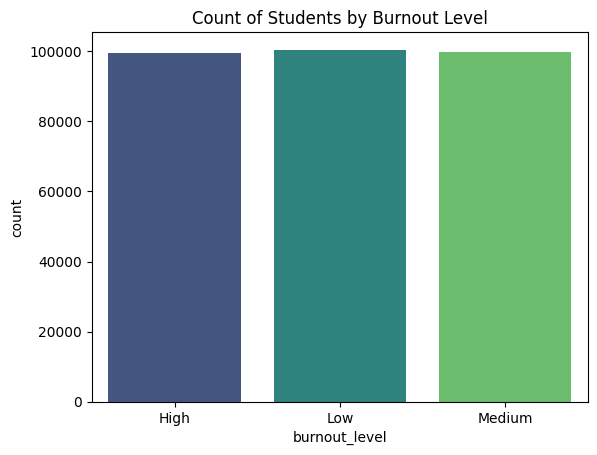

In [15]:
sns.countplot(data=df_combined, x='burnout_level', palette='viridis')
plt.title('Count of Students by Burnout Level')
plt.show() #bars even = data balance

In [17]:
print(df_combined.columns.tolist())

['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'stress_level', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours', 'sleep_quality', 'attendance_percentage', 'cgpa', 'internet_quality', 'burnout_level', 'source']


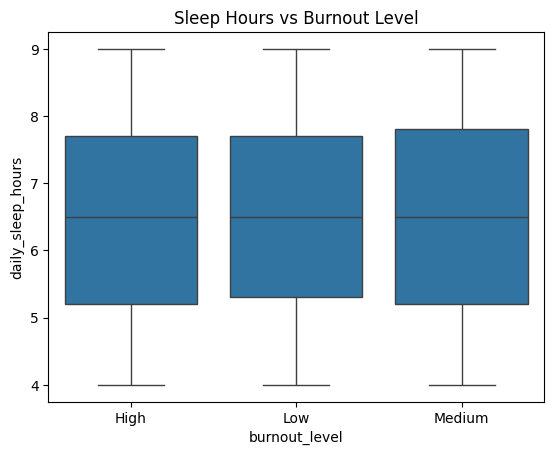

In [18]:
sns.boxplot(data=df_combined, x='burnout_level', y='daily_sleep_hours') ##Damount of sleep a student gets correlate with their burnout level?
plt.title('Sleep Hours vs Burnout Level')
plt.show()

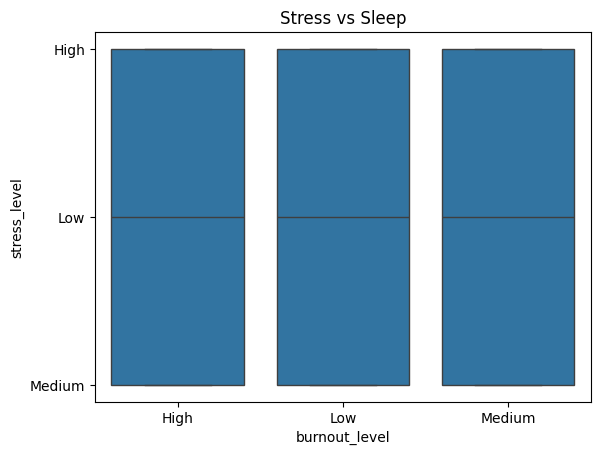

In [20]:
sns.boxplot(data=df_combined, x='burnout_level', y='stress_level')
plt.title('Stress vs Sleep')
plt.show()

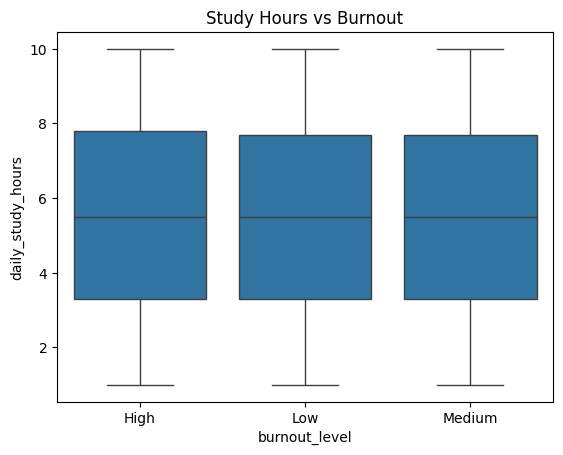

In [21]:
sns.boxplot(data=df_combined, x='burnout_level', y='daily_study_hours')
plt.title('Study Hours vs Burnout')
plt.show()

In [22]:
print(df_combined.groupby('burnout_level')['daily_sleep_hours'].describe())

                  count      mean       std  min  25%  50%  75%  max
burnout_level                                                       
High            99532.0  6.491595  1.444472  4.0  5.2  6.5  7.7  9.0
Low            100530.0  6.503482  1.439284  4.0  5.3  6.5  7.7  9.0
Medium          99938.0  6.502952  1.447814  4.0  5.2  6.5  7.8  9.0


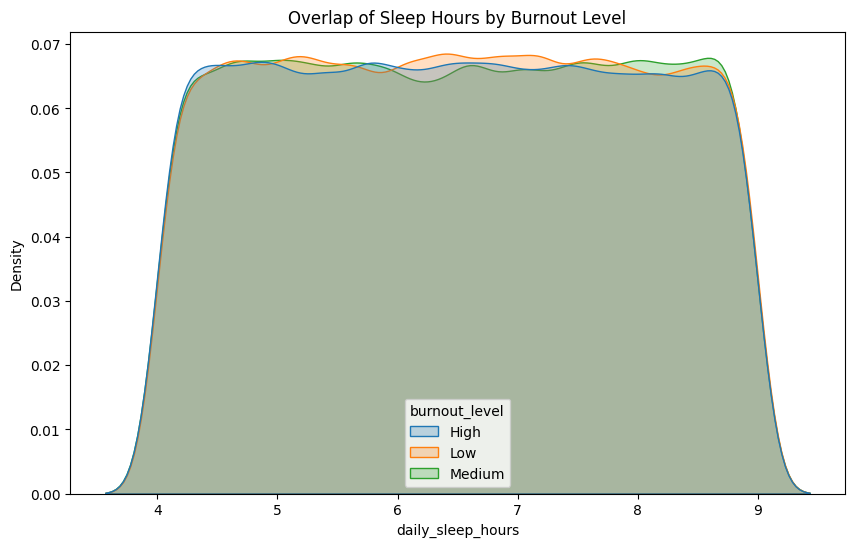

In [23]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df_combined, x='daily_sleep_hours', hue='burnout_level', fill=True)
plt.title('Overlap of Sleep Hours by Burnout Level')
plt.show()